In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
!pip install aeon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 18.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, QuantileTransformer, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
# from skopt import BayesSearchCV
# from skopt.space import Real, Integer, Categorical
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool
from aeon.regression.sklearn import RotationForestRegressor

In [49]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2
df['log_duration_min'] = np.log(df['duration_min'])
df['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

df_val['log_duration_min'] = np.log(df_val['duration_min'])
df_val['z_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

### Mini analisis

Distribucion del track_popularity por genero:

- Todos los generos se comportan de la misma manera, aunque con alguna diferencia en las caracteristicas de las curvas

<Axes: xlabel='track_popularity', ylabel='Density'>

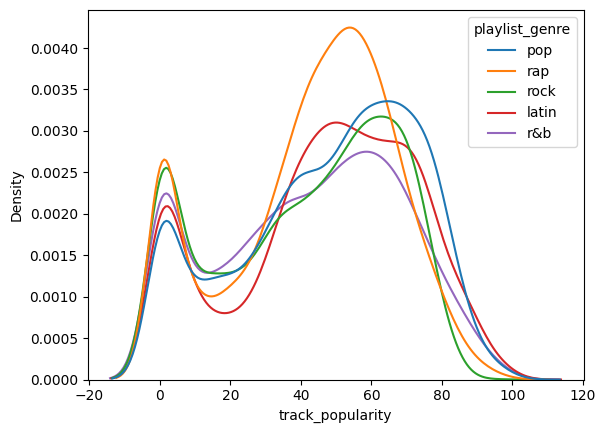

In [5]:
sns.kdeplot(data=df[['playlist_genre', 'track_popularity']], x='track_popularity', hue='playlist_genre')

Graficamos track_popularity promedio con una media movil de 500 y 1000 datos

<Axes: >

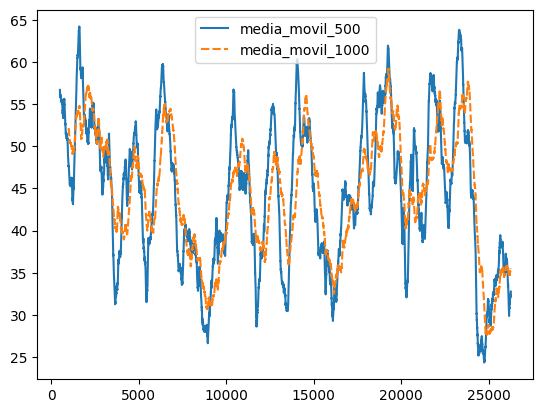

In [13]:
df.loc[df['track_popularity']!=0, 'media_movil_500'] = df['track_popularity'].rolling(500).mean()
df.loc[df['track_popularity']!=0, 'media_movil_1000'] = df['track_popularity'].rolling(1000).mean()

sns.lineplot(data=df[['media_movil_500', 'media_movil_1000']])

Graficamos cantidad de track_popularity igual a 0 cada 1000 observaciones

<Axes: >

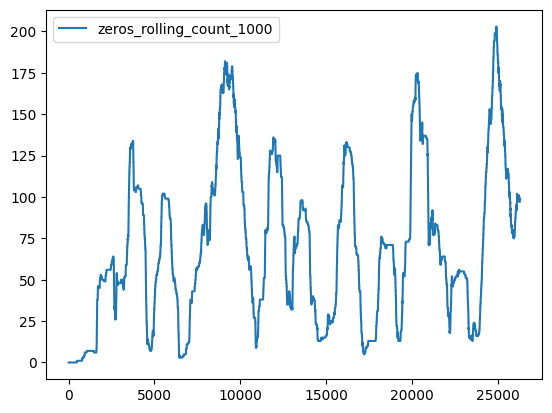

In [14]:
df['is_zero_popularity'] = (df['track_popularity'] == 0).astype(int)
df['zeros_rolling_count_1000'] = df['is_zero_popularity'].rolling(window=1000, min_periods=1).sum()

sns.lineplot(data=df[['zeros_rolling_count_1000']])

**Insight**: la media movil de cantidad de ceros cada 1000 observaciones tiene una correlacion muy alta (-0,78) con la media movil de track_popularity cada 1000 observaciones

In [16]:
df[['zeros_rolling_count_1000', 'media_movil_1000']].corr()

,zeros_rolling_count_1000,media_movil_1000
zeros_rolling_count_1000,1.000000,-0.782642
media_movil_1000,-0.782642,1.000000


### Catboost Full + Leakage (bilateral)

Volvemos a cargar el dataset y lo ponemos como el inicial

In [10]:
df_inicial = df[['Unnamed: 0', 'track_id', 'track_name', 'track_artist',
       'track_popularity', 'track_album_id', 'track_album_name',
       'playlist_name', 'playlist_id',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_min', 'grupo_anio', 'tonality']]

In [ ]:
cols_num = df_inicial.select_dtypes(include='number').columns
cols_num = cols_num.drop('track_popularity')
pd.concat([df_inicial[cols_num].mean(), df_val[cols_num].mean()], axis=1)

,0,1
Unnamed: 0,13132.483531,29549.000000
danceability,0.655717,0.651387
energy,0.677793,0.781819
loudness,-6.968511,-5.665154
speechiness,0.111771,0.088189
acousticness,0.193786,0.101632
instrumentalness,0.054890,0.204209
liveness,0.185225,0.209971
valence,0.535567,0.410537
tempo,119.957960,124.607046


Hacemos FE de distancias a la media pero con Leakage

In [7]:
df_inicial_FE = df_inicial.copy()

df_inicial_FE['distance_mean_danceability'] = (df_inicial_FE['danceability'] - df_val['danceability'].mean())
df_inicial_FE['distance_sq_mean_danceability'] = (df_inicial_FE['distance_mean_danceability'])**2

df_inicial_FE['distance_mean_energy'] = (df_inicial_FE['energy'] - df_val['energy'].mean())
df_inicial_FE['distance_sq_mean_energy'] = (df_inicial_FE['distance_mean_energy'])**2

df_inicial_FE['distance_mean_loudness'] = (df_inicial_FE['loudness'] - df_val['loudness'].mean())
df_inicial_FE['distance_sq_mean_loudness'] = (df_inicial_FE['distance_mean_loudness'])**2

df_inicial_FE['distance_mean_speechiness'] = (df_inicial_FE['speechiness'] - df_val['speechiness'].mean())
df_inicial_FE['distance_sq_mean_speechiness'] = (df_inicial_FE['distance_mean_speechiness'])**2

df_inicial_FE['distance_mean_acousticness'] = (df_inicial_FE['acousticness'] - df_val['acousticness'].mean())
df_inicial_FE['distance_sq_mean_acousticness'] = (df_inicial_FE['distance_mean_acousticness'])**2

df_inicial_FE['distance_mean_liveness'] = (df_inicial_FE['liveness'] - df_val['liveness'].mean())
df_inicial_FE['distance_sq_mean_liveness'] = (df_inicial_FE['distance_mean_liveness'])**2

df_inicial_FE['distance_mean_valence'] = (df_inicial_FE['valence'] - df_val['valence'].mean())
df_inicial_FE['distance_sq_mean_valence'] = (df_inicial_FE['distance_mean_valence'])**2

df_inicial_FE['distance_mean_tempo'] = (df_inicial_FE['tempo'] - df_val['tempo'].mean())
df_inicial_FE['distance_sq_mean_tempo'] = (df_inicial_FE['distance_mean_tempo'])**2

df_inicial_FE['distance_mean_duration_min'] = (df_inicial_FE['duration_min'] - df_val['duration_min'].mean())
df_inicial_FE['distance_sq_mean_duration_min'] = (df_inicial_FE['distance_mean_duration_min'])**2

In [ ]:
X = df_inicial_FE.drop(columns=['Unnamed: 0', 'track_popularity'])
y = df_inicial_FE['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
cat_features = X.select_dtypes(include='object').columns.tolist()

In [ ]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.015,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 0.0086291	total: 134ms	remaining: 2m 13s
100:	learn: 0.4141163	total: 4.86s	remaining: 43.3s
200:	learn: 0.4785393	total: 11.3s	remaining: 45.1s
300:	learn: 0.4951472	total: 17.3s	remaining: 40.3s
400:	learn: 0.5055688	total: 24.8s	remaining: 37s
500:	learn: 0.5131773	total: 30.9s	remaining: 30.8s
600:	learn: 0.5193277	total: 38.6s	remaining: 25.6s
700:	learn: 0.5254760	total: 49.3s	remaining: 21s
800:	learn: 0.5312350	total: 55.5s	remaining: 13.8s
900:	learn: 0.5359196	total: 1m 3s	remaining: 6.96s
999:	learn: 0.5406821	total: 1m 9s	remaining: 0us
TRAIN
R²:   0.7786
RMSE: 11.7499
TEST
R²:   0.5784
RMSE: 16.2712


### Catboost full plus + Leakage

In [26]:
cols_dropear = ['es0', 'track_popularity_bins', 'anio','duration_ms','log_duration_ms','z_duration_ms',
    'track_album_release_date', 'media_movil_50','media_movil_100','media_movil_500','media_movil_1000',
                'is_zero_popularity','zeros_rolling_count_1000']
cols_dropear+= [col for col in df.columns if 'distance' in col]

In [27]:
df_plus = df.drop(columns=cols_dropear)

In [29]:
df_plus_FE = df_plus.copy()

df_plus_FE['distance_mean_danceability'] = (df_plus_FE['danceability'] - df_val['danceability'].mean())
df_plus_FE['distance_sq_mean_danceability'] = (df_plus_FE['distance_mean_danceability'])**2

df_plus_FE['distance_mean_energy'] = (df_plus_FE['energy'] - df_val['energy'].mean())
df_plus_FE['distance_sq_mean_energy'] = (df_plus_FE['distance_mean_energy'])**2

df_plus_FE['distance_mean_loudness'] = (df_plus_FE['loudness'] - df_val['loudness'].mean())
df_plus_FE['distance_sq_mean_loudness'] = (df_plus_FE['distance_mean_loudness'])**2

df_plus_FE['distance_mean_speechiness'] = (df_plus_FE['speechiness'] - df_val['speechiness'].mean())
df_plus_FE['distance_sq_mean_speechiness'] = (df_plus_FE['distance_mean_speechiness'])**2

df_plus_FE['distance_mean_acousticness'] = (df_plus_FE['acousticness'] - df_val['acousticness'].mean())
df_plus_FE['distance_sq_mean_acousticness'] = (df_plus_FE['distance_mean_acousticness'])**2

df_plus_FE['distance_mean_liveness'] = (df_plus_FE['liveness'] - df_val['liveness'].mean())
df_plus_FE['distance_sq_mean_liveness'] = (df_plus_FE['distance_mean_liveness'])**2

df_plus_FE['distance_mean_valence'] = (df_plus_FE['valence'] - df_val['valence'].mean())
df_plus_FE['distance_sq_mean_valence'] = (df_plus_FE['distance_mean_valence'])**2

df_plus_FE['distance_mean_tempo'] = (df_plus_FE['tempo'] - df_val['tempo'].mean())
df_plus_FE['distance_sq_mean_tempo'] = (df_plus_FE['distance_mean_tempo'])**2

df_plus_FE['distance_mean_duration_min'] = (df_plus_FE['duration_min'] - df_val['duration_min'].mean())
df_plus_FE['distance_sq_mean_duration_min'] = (df_plus_FE['distance_mean_duration_min'])**2

In [42]:
X = df_plus_FE.drop(columns=['track_popularity'])
y = df_plus_FE['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
cat_features = X.select_dtypes(include='object').columns.tolist()

train_pool = Pool(X_train, y_train, cat_features=cat_features)

In [44]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.015,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 0.0088827	total: 103ms	remaining: 1m 42s
100:	learn: 0.4078544	total: 9.58s	remaining: 1m 25s
200:	learn: 0.4783590	total: 25.9s	remaining: 1m 42s
300:	learn: 0.4934709	total: 40.8s	remaining: 1m 34s
400:	learn: 0.5061895	total: 51.2s	remaining: 1m 16s
500:	learn: 0.5152931	total: 1m	remaining: 1m
600:	learn: 0.5227774	total: 1m 11s	remaining: 47.6s
700:	learn: 0.5297647	total: 1m 26s	remaining: 36.8s
800:	learn: 0.5359648	total: 1m 37s	remaining: 24.3s
900:	learn: 0.5411948	total: 1m 50s	remaining: 12.2s
999:	learn: 0.5457211	total: 2m 1s	remaining: 0us
TRAIN
R²:   0.7806
RMSE: 11.6955
TEST
R²:   0.5819
RMSE: 16.2037


#### Posible Submission

In [50]:
df_val_FE = df_val.copy()

df_val_FE['distance_mean_danceability'] = (df_val_FE['danceability'] - df_val['danceability'].mean())
df_val_FE['distance_sq_mean_danceability'] = (df_val_FE['distance_mean_danceability'])**2

df_val_FE['distance_mean_energy'] = (df_val_FE['energy'] - df_val['energy'].mean())
df_val_FE['distance_sq_mean_energy'] = (df_val_FE['distance_mean_energy'])**2

df_val_FE['distance_mean_loudness'] = (df_val_FE['loudness'] - df_val['loudness'].mean())
df_val_FE['distance_sq_mean_loudness'] = (df_val_FE['distance_mean_loudness'])**2

df_val_FE['distance_mean_speechiness'] = (df_val_FE['speechiness'] - df_val['speechiness'].mean())
df_val_FE['distance_sq_mean_speechiness'] = (df_val_FE['distance_mean_speechiness'])**2

df_val_FE['distance_mean_acousticness'] = (df_val_FE['acousticness'] - df_val['acousticness'].mean())
df_val_FE['distance_sq_mean_acousticness'] = (df_val_FE['distance_mean_acousticness'])**2

df_val_FE['distance_mean_liveness'] = (df_val_FE['liveness'] - df_val['liveness'].mean())
df_val_FE['distance_sq_mean_liveness'] = (df_val_FE['distance_mean_liveness'])**2

df_val_FE['distance_mean_valence'] = (df_val_FE['valence'] - df_val['valence'].mean())
df_val_FE['distance_sq_mean_valence'] = (df_val_FE['distance_mean_valence'])**2

df_val_FE['distance_mean_tempo'] = (df_val_FE['tempo'] - df_val['tempo'].mean())
df_val_FE['distance_sq_mean_tempo'] = (df_val_FE['distance_mean_tempo'])**2

df_val_FE['distance_mean_duration_min'] = (df_val_FE['duration_min'] - df_val['duration_min'].mean())
df_val_FE['distance_sq_mean_duration_min'] = (df_val_FE['distance_mean_duration_min'])**2

In [53]:
y_val_predicted = model.predict(df_val_FE[X_train.columns.to_list()])

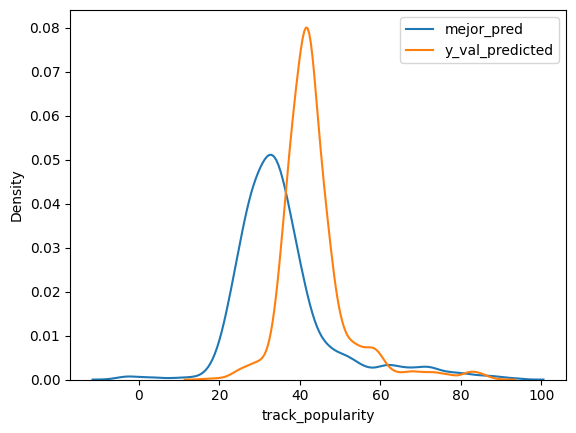

In [55]:
mejor_pred = pd.read_csv('/content/catboost_full_track_id_imputation_moved-5.csv')

sns.kdeplot(mejor_pred['track_popularity'], label='mejor_pred')
sns.kdeplot(y_val_predicted, label='y_val_predicted')
plt.legend()
plt.show()

In [56]:
df_possible_submissions = pd.DataFrame({'ID': df_val['Unnamed: 0'], 'track_popularity_full_leakage': y_val_predicted})

#### Less Iter

Probamos con menos iteraciones

In [35]:
model_less_iter = CatBoostRegressor(
    iterations=600,
    learning_rate=0.02,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model_less_iter.fit(train_pool)

print('TRAIN')
y_pred_less_iter = model_less_iter.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred_less_iter):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_less_iter)):.4f}")

print('TEST')
y_pred_less_iter = model_less_iter.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_less_iter):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_less_iter)):.4f}")

0:	learn: 0.0118139	total: 101ms	remaining: 1m
100:	learn: 0.4523267	total: 9.36s	remaining: 46.2s
200:	learn: 0.4911868	total: 19.6s	remaining: 38.8s
300:	learn: 0.5074615	total: 29.3s	remaining: 29.1s
400:	learn: 0.5193520	total: 40s	remaining: 19.8s
500:	learn: 0.5286060	total: 50.6s	remaining: 10s
599:	learn: 0.5363616	total: 1m 1s	remaining: 0us
TRAIN
R²:   0.7745
RMSE: 11.8566
TEST
R²:   0.5777
RMSE: 16.2838


#### Sacamos track_popularity = 0

Probamos sacando de entrenamiento datos con 0

In [37]:
print(df_plus_FE.shape[0])

26261


In [57]:
X = df_plus_FE[df_plus_FE['track_popularity'] != 0].drop(columns=['track_popularity'])
y = df_plus_FE.loc[df_plus_FE['track_popularity'] != 0, 'track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
print(X_train.shape[0] + X_test.shape[0])

24366


In [58]:
cat_features = X.select_dtypes(include='object').columns.tolist()

train_pool = Pool(X_train, y_train, cat_features=cat_features)

In [59]:
model_no0 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.02,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model_no0.fit(train_pool)

print('TRAIN')
y_pred_no0 = model_no0.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred_no0):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_no0)):.4f}")

print('TEST')
y_pred_no0 = model_no0.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_no0):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_no0)):.4f}")

0:	learn: 0.0102615	total: 102ms	remaining: 1m 41s
100:	learn: 0.4281637	total: 11.8s	remaining: 1m 45s
200:	learn: 0.4687922	total: 21.8s	remaining: 1m 26s
300:	learn: 0.4843344	total: 33.2s	remaining: 1m 17s
400:	learn: 0.4955230	total: 47.2s	remaining: 1m 10s
500:	learn: 0.5051965	total: 57.4s	remaining: 57.2s
600:	learn: 0.5150936	total: 1m 6s	remaining: 44.4s
700:	learn: 0.5232579	total: 1m 17s	remaining: 33s
800:	learn: 0.5309665	total: 1m 27s	remaining: 21.8s
900:	learn: 0.5376219	total: 1m 38s	remaining: 10.8s
999:	learn: 0.5439024	total: 1m 46s	remaining: 0us
TRAIN
R²:   0.7697
RMSE: 10.8124
TEST
R²:   0.5240
RMSE: 15.4541


In [61]:
y_val_predicted_no0 = model_no0.predict(df_val_FE[X_train.columns.to_list()])

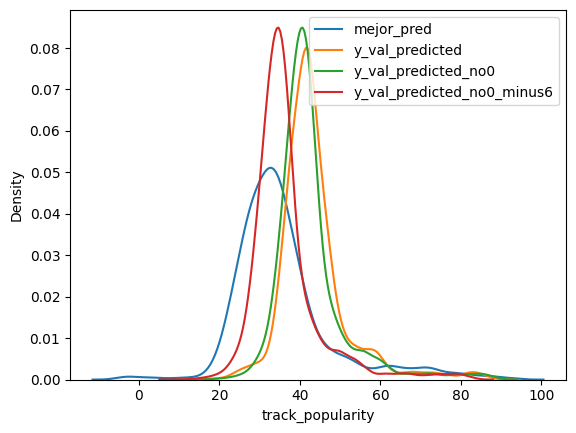

In [66]:
sns.kdeplot(mejor_pred['track_popularity'], label='mejor_pred')
sns.kdeplot(y_val_predicted, label='y_val_predicted')
sns.kdeplot(y_val_predicted_no0, label='y_val_predicted_no0')
sns.kdeplot(y_val_predicted_no0 - 6, label='y_val_predicted_no0_minus6')
plt.legend()
plt.show()

In [ ]:
pd.DataFrame({'ID':df_val_FE['Unnamed: 0']})

#### Submission 1 y 2

### Catboost full + Leakage + track_id

In [ ]:
# Calculate the average track_popularity for each track_id in df
track_popularity_avg_df = df.groupby('track_id')['track_popularity'].mean()

# Populate y_val_predicted_track_id_avg by mapping track_id from df_val
# The index of the resulting Series will be df_val['Unnamed: 0'], and values will be
# the average popularity if a track_id match is found, otherwise NaN.
y_val_predicted_track_id_avg = df_val.set_index('Unnamed: 0')['track_id'].map(track_popularity_avg_df)

# The variable y_val_predicted_track_id_avg now contains the desired predictions,
# correctly indexed by 'Unnamed: 0' and with NaNs where track_id was not found in df.

# Ensure y_val_pred has the same index as df_val['Unnamed: 0'] for proper alignment
y_val_pred_series = pd.Series(y_val_pred, index=df_val['Unnamed: 0'])


# Combine the two prediction series:
# If y_val_predicted_track_id_avg_aligned has a value (not NaN), use it.
# Otherwise, use the value from y_val_pred_series.
y_val_combined_predictions = y_val_predicted_track_id_avg.fillna(y_val_pred_series)

# Create a DataFrame for the final predictions, ensuring 'ID' matches 'Unnamed: 0' from df_val
# y_val_combined_predictions is already indexed by the 'Unnamed: 0' values.
# So, we can directly use its index for the 'ID' column and its values for 'track_popularity'.
submission_df_combined_track_id = pd.DataFrame({
    'ID': y_val_combined_predictions.index,
    'track_popularity_track_id': y_val_combined_predictions.values
})

print(submission_df_combined_track_id.head())

### Catboost Reduced + Leakage

Sacamos algunas variables que podian hacer muy notable el overfitting

In [ ]:
X_reduced = X.drop(columns=['track_name','track_album_name','playlist_name','playlist_id','playlist_genre','playlist_subgenre'])

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

cat_features = X_reduced.select_dtypes(include='object').columns.tolist()

train_pool = Pool(X_train, y_train, cat_features=cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.01,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 0.0057515	total: 38.5ms	remaining: 46.1s
100:	learn: 0.2763673	total: 2.57s	remaining: 28s
200:	learn: 0.3715233	total: 5.02s	remaining: 25s
300:	learn: 0.3936935	total: 8.48s	remaining: 25.3s
400:	learn: 0.4037978	total: 12.4s	remaining: 24.8s
500:	learn: 0.4117421	total: 15.9s	remaining: 22.1s
600:	learn: 0.4174453	total: 19.2s	remaining: 19.2s
700:	learn: 0.4220967	total: 23.9s	remaining: 17s
800:	learn: 0.4262659	total: 27.4s	remaining: 13.7s
900:	learn: 0.4304556	total: 31s	remaining: 10.3s
1000:	learn: 0.4342618	total: 35.6s	remaining: 7.07s
1100:	learn: 0.4381717	total: 39.5s	remaining: 3.55s
1199:	learn: 0.4418432	total: 43.1s	remaining: 0us
TRAIN
R²:   0.7625
RMSE: 12.1674
TEST
R²:   0.4856
RMSE: 17.9721


#### Submission

In [ ]:
df_val_inicial = df_val[['Unnamed: 0', 'track_id', 'track_name', 'track_artist',
       'track_album_id', 'track_album_name',
       'playlist_name', 'playlist_id',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_min', 'grupo_anio', 'tonality']].copy()

In [ ]:
df_val_inicial_FE = df_val_inicial.copy()
df_val_inicial_FE = df_val_inicial_FE.drop(columns=['Unnamed: 0', 'track_name','track_album_name','playlist_name','playlist_id','playlist_genre','playlist_subgenre'])

df_val_inicial_FE['distance_mean_danceability'] = (df_val_inicial_FE['danceability'] - df_val['danceability'].mean())
df_val_inicial_FE['distance_sq_mean_danceability'] = (df_val_inicial_FE['distance_mean_danceability'])**2

df_val_inicial_FE['distance_mean_energy'] = (df_val_inicial_FE['energy'] - df_val['energy'].mean())
df_val_inicial_FE['distance_sq_mean_energy'] = (df_val_inicial_FE['distance_mean_energy'])**2

df_val_inicial_FE['distance_mean_loudness'] = (df_val_inicial_FE['loudness'] - df_val['loudness'].mean())
df_val_inicial_FE['distance_sq_mean_loudness'] = (df_val_inicial_FE['distance_mean_loudness'])**2

df_val_inicial_FE['distance_mean_speechiness'] = (df_val_inicial_FE['speechiness'] - df_val['speechiness'].mean())
df_val_inicial_FE['distance_sq_mean_speechiness'] = (df_val_inicial_FE['distance_mean_speechiness'])**2

df_val_inicial_FE['distance_mean_acousticness'] = (df_val_inicial_FE['acousticness'] - df_val['acousticness'].mean())
df_val_inicial_FE['distance_sq_mean_acousticness'] = (df_val_inicial_FE['distance_mean_acousticness'])**2

df_val_inicial_FE['distance_mean_liveness'] = (df_val_inicial_FE['liveness'] - df_val['liveness'].mean())
df_val_inicial_FE['distance_sq_mean_liveness'] = (df_val_inicial_FE['distance_mean_liveness'])**2

df_val_inicial_FE['distance_mean_valence'] = (df_val_inicial_FE['valence'] - df_val['valence'].mean())
df_val_inicial_FE['distance_sq_mean_valence'] = (df_val_inicial_FE['distance_mean_valence'])**2

df_val_inicial_FE['distance_mean_tempo'] = (df_val_inicial_FE['tempo'] - df_val['tempo'].mean())
df_val_inicial_FE['distance_sq_mean_tempo'] = (df_val_inicial_FE['distance_mean_tempo'])**2

df_val_inicial_FE['distance_mean_duration_min'] = (df_val_inicial_FE['duration_min'] - df_val['duration_min'].mean())
df_val_inicial_FE['distance_sq_mean_duration_min'] = (df_val_inicial_FE['distance_mean_duration_min'])**2

In [ ]:
y_val_predicted = model.predict(df_val_inicial_FE[X_reduced.columns.tolist()])

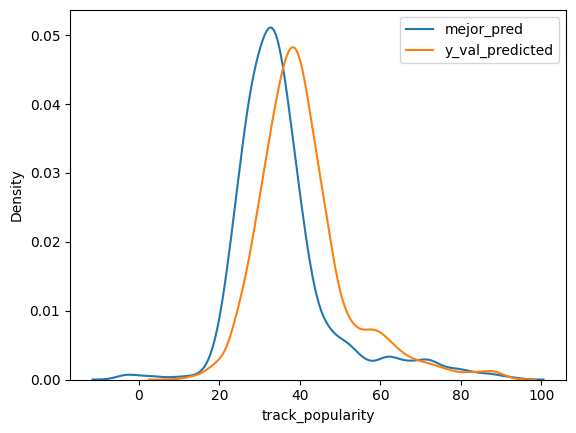

In [ ]:
mejor_pred = pd.read_csv('/content/catboost_full_track_id_imputation_moved-5.csv')

sns.kdeplot(mejor_pred['track_popularity'], label='mejor_pred')
sns.kdeplot(y_val_predicted, label='y_val_predicted')
plt.legend()
plt.show()

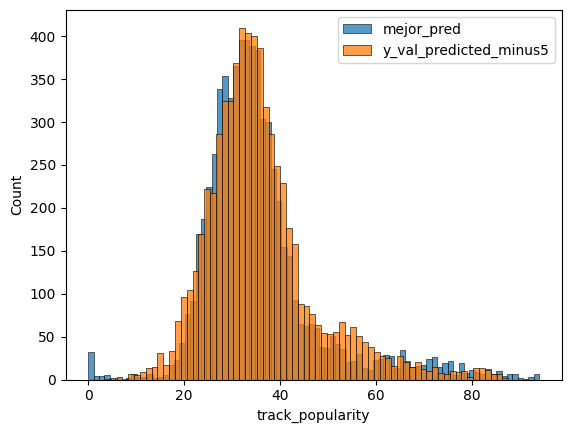

In [ ]:
sns.histplot(mejor_pred['track_popularity'].clip(lower=0), label='mejor_pred')
# sns.histplot(y_val_predicted, label='y_val_predicted')
sns.histplot(y_val_predicted - 5, label='y_val_predicted_minus5')
plt.legend()
plt.show()

In [ ]:
# Al final le restamos 6
submision_df = pd.DataFrame({'ID': df_val_inicial['Unnamed: 0'], 'track_popularity': y_val_predicted - 6})

In [ ]:
submision_df.to_csv('catboost_with_leakage.csv', index=False)

In [ ]:
submision_df_bis = submision_df.copy()

submision_df_bis.loc[submision_df_bis['track_popularity'] < 42, 'track_popularity'] -= 7
submision_df_bis.loc[submision_df_bis['track_popularity'] >= 42, 'track_popularity'] += 5
submision_df_bis['track_popularity'] = submision_df_bis['track_popularity'].clip(lower=0)

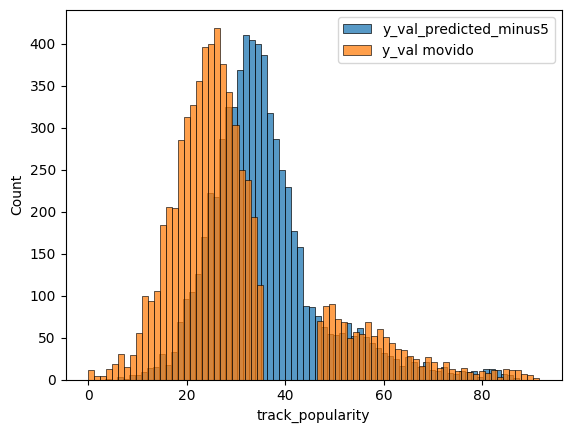

In [ ]:
sns.histplot(y_val_predicted - 5, label='y_val_predicted_minus5')
sns.histplot(submision_df_bis['track_popularity'], label='y_val movido')
plt.legend()
plt.show()

In [ ]:
submision_df_bis.to_csv('catboost_with_leakage_moved.csv', index=False)

### Modelo solo R&B

In [ ]:
df_val_rnb = df_val[df_val['playlist_genre'] == 'r&b'].copy()

In [ ]:
ids_rnb = df_val_rnb['Unnamed: 0'].values.tolist()

In [ ]:
df_rnb = df[df['playlist_genre'] == 'r&b']

<Axes: ylabel='Frequency'>

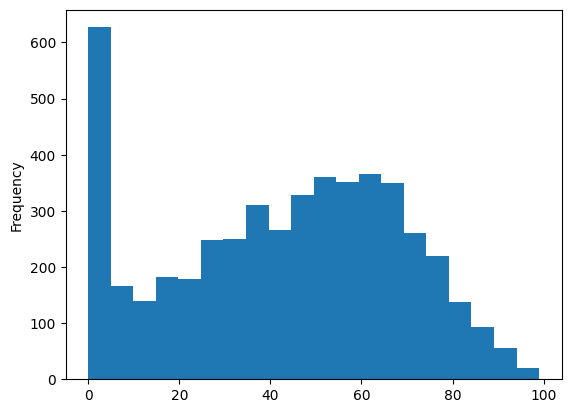

In [ ]:
df_rnb['track_popularity'].plot(kind='hist',bins=20)

In [ ]:
df_rnb.shape

(4907, 97)

In [ ]:
for col in ['track_id', 'track_name', 'track_artist','track_popularity', 'track_album_id', 'track_album_name','playlist_name', 'playlist_id','playlist_genre', 'playlist_subgenre', 'grupo_anio', 'tonality']:
  print(f'COLUMNA: {col} tienen {df_rnb[col].nunique()} valores unicos')

COLUMNA: track_id tienen 4634 valores unicos
COLUMNA: track_name tienen 4120 valores unicos
COLUMNA: track_artist tienen 2004 valores unicos
COLUMNA: track_popularity tienen 100 valores unicos
COLUMNA: track_album_id tienen 3426 valores unicos
COLUMNA: track_album_name tienen 3205 valores unicos
COLUMNA: playlist_name tienen 71 valores unicos
COLUMNA: playlist_id tienen 75 valores unicos
COLUMNA: playlist_genre tienen 1 valores unicos
COLUMNA: playlist_subgenre tienen 4 valores unicos
COLUMNA: grupo_anio tienen 11 valores unicos
COLUMNA: tonality tienen 24 valores unicos


In [ ]:
# X = df_rnb[['most_extreme_feature','grupo_anio','tonality','len_playlist_name', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
#        'liveness', 'valence', 'tempo', 'distance_mean_danceability','distance_sq_mean_danceability', 'distance_mean_energy',
#        'distance_sq_mean_energy', 'distance_mean_loudness','distance_sq_mean_loudness', 'distance_mean_speechiness','distance_sq_mean_speechiness', 'distance_mean_acousticness',
#        'distance_sq_mean_acousticness', 'distance_mean_liveness','distance_sq_mean_liveness', 'distance_mean_valence','distance_sq_mean_valence', 'distance_mean_tempo',
#        'distance_sq_mean_tempo', 'dance_energy', 'happy_energy',
#        'acoustic_instr', 'duration_min', 'track_age', 'log_instrumentalness', 'log_speechiness',
#        'log_liveness', 'z_danceability', 'z_energy', 'z_loudness', 'z_tempo',
#        'z_valence', 'z_acousticness', 'z_instrumentalness', 'z_speechiness', 'global_atipicality', 'max_z_score',
#         'mood_score', 'chill_score', 'melancholy_score',
#        'radio_friendly', 'club_score', 'acoustic_contrast', 'mood_complexity',
#        'dance_val_tension', 'vocal_presence', 'pure_instrumental',
#        'spoken_word', 'loudness_abs', 'loudness_energy_ratio',
#        'dynamic_compression', 'live_vocal', 'studio_clean', 'danceability_sq',
#        'danceability_sqrt', 'energy_sq', 'energy_sqrt', 'valence_sq',
#        'valence_sqrt', 'loudness_abs_sq', 'loudness_abs_sqrt', 'distance_mean_duration_min', 'distance_sq_mean_duration_min',
#        'log_duration_min', 'z_duration_min']]
X = df_rnb[['most_extreme_feature','grupo_anio','tonality','len_playlist_name', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'tempo', 'distance_mean_danceability','distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness','distance_sq_mean_loudness', 'distance_mean_speechiness','distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness','distance_sq_mean_liveness', 'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'radio_friendly', 'dance_val_tension']]
y = df_rnb['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [ ]:
cat_features = X.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train, y_train, cat_features=cat_features)

In [ ]:
print('MODELO R&B')
modelrnb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.015,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
modelrnb.fit(train_pool)

print('TRAIN')
y_pred = modelrnb.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = modelrnb.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

MODELO R&B
0:	learn: 0.0054529	total: 16.7ms	remaining: 16.7s
100:	learn: 0.2326411	total: 1.15s	remaining: 10.3s
200:	learn: 0.2891821	total: 2.26s	remaining: 8.98s
300:	learn: 0.3207792	total: 3.92s	remaining: 9.11s
400:	learn: 0.3461172	total: 5.37s	remaining: 8.02s
500:	learn: 0.3671216	total: 6.49s	remaining: 6.46s
600:	learn: 0.3863498	total: 7.62s	remaining: 5.06s
700:	learn: 0.4058727	total: 8.75s	remaining: 3.73s
800:	learn: 0.4254800	total: 10.7s	remaining: 2.67s
900:	learn: 0.4444919	total: 12.3s	remaining: 1.35s
999:	learn: 0.4617985	total: 13.4s	remaining: 0us
TRAIN
R²:   0.4456
RMSE: 19.3273
TEST
R²:   0.2363
RMSE: 21.6482


In [ ]:
pd.DataFrame({'columnas':X.columns.tolist(), 'importancia': modelrnb.feature_importances_}).sort_values(by='importancia', ascending=False)

,columnas,importancia
1,grupo_anio,22.908466
3,len_playlist_name,10.878698
16,distance_mean_loudness,4.627147
9,instrumentalness,4.134582
2,tonality,3.977951
6,loudness,3.896054
14,distance_mean_energy,3.425683
5,energy,3.403545
0,most_extreme_feature,3.266586
27,radio_friendly,2.822328


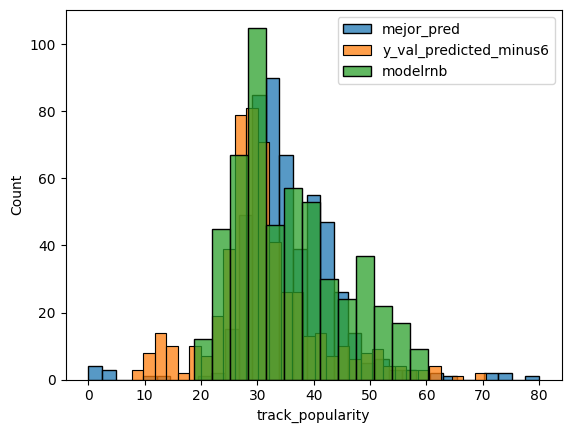

In [ ]:
sns.histplot(mejor_pred.loc[mejor_pred['ID'].isin(ids_rnb), 'track_popularity'].clip(lower=0), label='mejor_pred')
sns.histplot(submision_df.loc[submision_df['ID'].isin(ids_rnb), 'track_popularity'], label='y_val_predicted_minus6')
sns.histplot(modelrnb.predict(df_val_rnb[X.columns.tolist()]), label='modelrnb')
plt.legend()
plt.show()

In [ ]:
X_train = X_train.drop(columns=X_train.select_dtypes(include='object').columns.to_list())
X_test = X_test.drop(columns=X_train.select_dtypes(include='object').columns.to_list())

In [ ]:
preprocesador_avanzado = ColumnTransformer(
    transformers=[
        # Convierte las variables a una distribución normal, reduciendo el impacto de outliers
        # y ayudando al PCA a encontrar mejores componentes estables.
        ('transformacion_no_lineal', QuantileTransformer(output_distribution='normal', random_state=42), X_train.select_dtypes(include='number').columns.to_list())
    ],
    remainder='passthrough'
)

pipeline_avanzado = Pipeline([
    ('preprocesamiento', preprocesador_avanzado),
    ('rotation_forest', RotationForestRegressor(n_estimators=500, random_state=42))
])

# Ahora entrenás este objeto contenedor
pipeline_avanzado.fit(X_train, y_train)

print('Prediccion TRAIN')
y_train_pred_pipeline_final = pipeline_avanzado.predict(X_train)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred_pipeline_final):.4f}")

print('Prediccion TEST')
y_pred_pipeline_final = pipeline_avanzado.predict(X_test)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 11.3633
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 3.3710
Coeficiente de Determinación (R²): 0.9831
Prediccion TEST
Error Cuadrático Medio (MSE): 518.1197
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 22.7622
Coeficiente de Determinación (R²): 0.1557


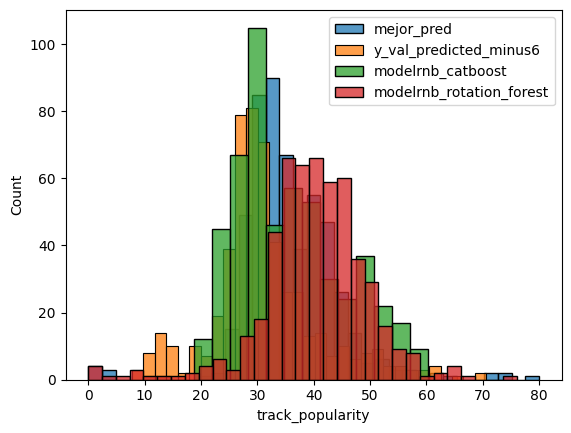

In [ ]:
sns.histplot(mejor_pred.loc[mejor_pred['ID'].isin(ids_rnb), 'track_popularity'].clip(lower=0), label='mejor_pred')
sns.histplot(submision_df.loc[submision_df['ID'].isin(ids_rnb), 'track_popularity'], label='y_val_predicted_minus6')
sns.histplot(modelrnb.predict(df_val_rnb[X.columns.tolist()]), label='modelrnb_catboost')
sns.histplot(pipeline_avanzado.predict(df_val_rnb[X_train.columns.tolist()]), label='modelrnb_rotation_forest')

plt.legend()
plt.show()